# Surface Analysis for the 2011 Super Outbreak

This notebook will map station plots to see how the 2011 Super Outbreak was handled in comparison to the reanalysis.
Most of this code is from the surface-plots notebook from ATM350.

In [1]:
from datetime import datetime,timedelta
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import cartopy.crs as ccrs
import cartopy.feature as cfeature

from metpy.calc import wind_components, reduce_point_density
from metpy.units import units
from metpy.plots import StationPlot
from metpy.plots.wx_symbols import current_weather, sky_cover, wx_code_map

# Load in a collection of functions that process GEMPAK weather conditions and cloud cover data.
%run /kt11/ktyle/python/metargem.py

In [3]:
validTime = datetime(2011, 4, 26, 12)
year = 2011
month = 4
day = 26
hour = 12
minute = 0

timeStr = validTime.strftime("%Y-%m-%d %H UTC")
timeStr2 = validTime.strftime("%Y%m%d%H")
YYMMDDHH = validTime.strftime("%y%m%d%H")
print(timeStr)
print(validTime)

2011-04-26 12 UTC
2011-04-26 12:00:00


In [7]:
df = pd.read_csv('asos2011.csv')

In [8]:
df

,station,valid,lon,lat,elevation,tmpf,dwpf,relh,drct,sknt,...,wxcodes,ice_accretion_1hr,ice_accretion_3hr,ice_accretion_6hr,peak_wind_gust,peak_wind_drct,peak_wind_time,feel,metar,snowdepth
0,PQL,2011-04-25 00:13,-88.5319,30.4636,5.0,75.2,69.80,83.32,140.0,7.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,76.34,KPQL 250013Z AUTO 14007KT 10SM FEW014 SCT019 B...,NaN
1,CRX,2011-04-25 00:15,-88.6035,34.9150,129.0,75.2,62.60,64.91,160.0,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,75.20,KCRX 250015Z AUTO 16005KT 10SM CLR 24/17 A2994...,NaN
2,M16,2011-04-25 00:15,-90.4105,32.3045,75.3,77.0,62.60,61.13,150.0,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,77.00,KM16 250015Z AUTO 15005KT 10SM CLR 25/17 A2992...,NaN
3,CKM,2011-04-25 00:15,-90.5123,34.2997,52.7,78.8,62.60,57.60,170.0,8.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,80.31,KCKM 250015Z AUTO 17008KT 10SM CLR 26/17 A2989...,NaN
4,1R7,2011-04-25 00:15,-90.4093,31.6058,149.0,78.8,64.40,61.36,150.0,8.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,80.56,K1R7 250015Z AUTO 15008G14KT 020V020 8SM CLR 2...,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2623,UOX,2011-04-26 23:55,-89.5368,34.3843,137.8,75.2,62.60,64.91,160.0,4.0,...,TS,NaN,NaN,NaN,NaN,NaN,NaN,75.20,KUOX 262355Z AUTO 16004KT 10SM TS CLR 24/17 A2...,NaN
2624,CBM,2011-04-26 23:55,-88.4438,33.6438,67.0,79.0,62.78,57.63,170.0,16.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,80.49,KCBM 262355Z AUTO 17016G22KT 10SM SCT090 26/17...,NaN
2625,MIS,2011-04-26 23:55,-88.8420,29.2960,32.0,84.2,75.20,74.44,210.0,13.0,...,HZ,NaN,NaN,NaN,NaN,NaN,NaN,92.45,KMIS 262355Z AUTO 21013G18KT 1 3/4SM HZ CLR 29...,NaN
2626,NMM,2011-04-26 23:56,-88.5556,32.5521,97.0,78.0,65.00,64.03,140.0,7.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,78.08,KNMM 262356Z 14007KT 120V190 10SM FEW040 SCT25...,NaN


In [30]:
# set the bounds
lonW = -92
lonE = -88
latS = 30
latN = 35.5
cLat, cLon = (latS + latN)/2, (lonW + lonE)/2

df2 = df.query('lat >= @latS & lat <= @latN  & lon >= @lonW  & lon <= @lonE')
df2

,station,valid,lon,lat,elevation,tmpf,dwpf,relh,drct,sknt,...,wxcodes,ice_accretion_1hr,ice_accretion_3hr,ice_accretion_6hr,peak_wind_gust,peak_wind_drct,peak_wind_time,feel,metar,snowdepth
0,PQL,2011-04-25 00:13,-88.5319,30.4636,5.0,75.2,69.80,83.32,140.0,7.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,76.34,KPQL 250013Z AUTO 14007KT 10SM FEW014 SCT019 B...,NaN
1,CRX,2011-04-25 00:15,-88.6035,34.9150,129.0,75.2,62.60,64.91,160.0,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,75.20,KCRX 250015Z AUTO 16005KT 10SM CLR 24/17 A2994...,NaN
2,M16,2011-04-25 00:15,-90.4105,32.3045,75.3,77.0,62.60,61.13,150.0,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,77.00,KM16 250015Z AUTO 15005KT 10SM CLR 25/17 A2992...,NaN
3,CKM,2011-04-25 00:15,-90.5123,34.2997,52.7,78.8,62.60,57.60,170.0,8.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,80.31,KCKM 250015Z AUTO 17008KT 10SM CLR 26/17 A2989...,NaN
4,1R7,2011-04-25 00:15,-90.4093,31.6058,149.0,78.8,64.40,61.36,150.0,8.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,80.56,K1R7 250015Z AUTO 15008G14KT 020V020 8SM CLR 2...,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2622,HSA,2011-04-26 23:55,-89.4546,30.3678,7.0,77.0,77.00,100.00,150.0,15.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,77.00,KHSA 262355Z 15015G20KT 7SM BKN016 BKN025 25/2...,NaN
2623,UOX,2011-04-26 23:55,-89.5368,34.3843,137.8,75.2,62.60,64.91,160.0,4.0,...,TS,NaN,NaN,NaN,NaN,NaN,NaN,75.20,KUOX 262355Z AUTO 16004KT 10SM TS CLR 24/17 A2...,NaN
2624,CBM,2011-04-26 23:55,-88.4438,33.6438,67.0,79.0,62.78,57.63,170.0,16.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,80.49,KCBM 262355Z AUTO 17016G22KT 10SM SCT090 26/17...,NaN
2626,NMM,2011-04-26 23:56,-88.5556,32.5521,97.0,78.0,65.00,64.03,140.0,7.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,78.08,KNMM 262356Z 14007KT 120V190 10SM FEW040 SCT25...,NaN


In [31]:
columns = ['station', 'valid', 'lat', 'lon', 'elevation', 'tmpf', 'dwpf', 'alti','mslp',
                'sknt', 'drct','alti','vsby','skyc1', 'skyc2', 'skyc3']
df3 = df2[columns]
df3

,station,valid,lat,lon,elevation,tmpf,dwpf,alti,mslp,sknt,drct,alti,vsby,skyc1,skyc2,skyc3
0,PQL,2011-04-25 00:13,30.4636,-88.5319,5.0,75.2,69.80,30.02,NaN,7.0,140.0,30.02,10.0,FEW,SCT,BKN
1,CRX,2011-04-25 00:15,34.9150,-88.6035,129.0,75.2,62.60,29.94,NaN,5.0,160.0,29.94,10.0,CLR,,
2,M16,2011-04-25 00:15,32.3045,-90.4105,75.3,77.0,62.60,29.92,NaN,5.0,150.0,29.92,10.0,CLR,,
3,CKM,2011-04-25 00:15,34.2997,-90.5123,52.7,78.8,62.60,29.89,NaN,8.0,170.0,29.89,10.0,CLR,,
4,1R7,2011-04-25 00:15,31.6058,-90.4093,149.0,78.8,64.40,29.96,NaN,8.0,150.0,29.96,8.0,CLR,,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2622,HSA,2011-04-26 23:55,30.3678,-89.4546,7.0,77.0,77.00,29.67,NaN,15.0,150.0,29.67,7.0,BKN,BKN,
2623,UOX,2011-04-26 23:55,34.3843,-89.5368,137.8,75.2,62.60,29.57,NaN,4.0,160.0,29.57,10.0,CLR,,
2624,CBM,2011-04-26 23:55,33.6438,-88.4438,67.0,79.0,62.78,29.64,NaN,16.0,170.0,29.64,10.0,SCT,,
2626,NMM,2011-04-26 23:56,32.5521,-88.5556,97.0,78.0,65.00,29.66,1005.0,7.0,140.0,29.66,10.0,FEW,SCT,


In [32]:
# replacing missing values into a readable format
df4 = df3.replace(-9999.0, np.nan)
data1 = df4

In [33]:
# data1.loc[data1['WNUM'] =='********', ['WNUM']] = '-9999.00'
# data1['WNUM'] = data1['WNUM'].astype('float16')

In [38]:
lats = data1['lat'].values
lons = data1['lon'].values
tair = data1['tmpf'].values 
dewp = data1['dwpf'].values 
altm = (data1['alti'].values * units('inHg')).to('mbar')
slp = data1['mslp'].values * units('hPa')

# separate wind to components
u, v = wind_components(data1['sknt'].values * units.knots, data1['drct'].values * units.degree)

# # Need to handle missing (NaN) and convert to proper code
# chc1 = (np.nan_to_num(data1['skyc1'].values,True).astype(int))
# chc2 = (np.nan_to_num(data1['skyc2'].values,True).astype(int))
# chc3 = (np.nan_to_num(data1['skyc3'].values,True).astype(int))
# cloud_cover = calc_clouds(chc1, chc2, chc3)

# set a variable for plotting the station id's
stid = data1['station']

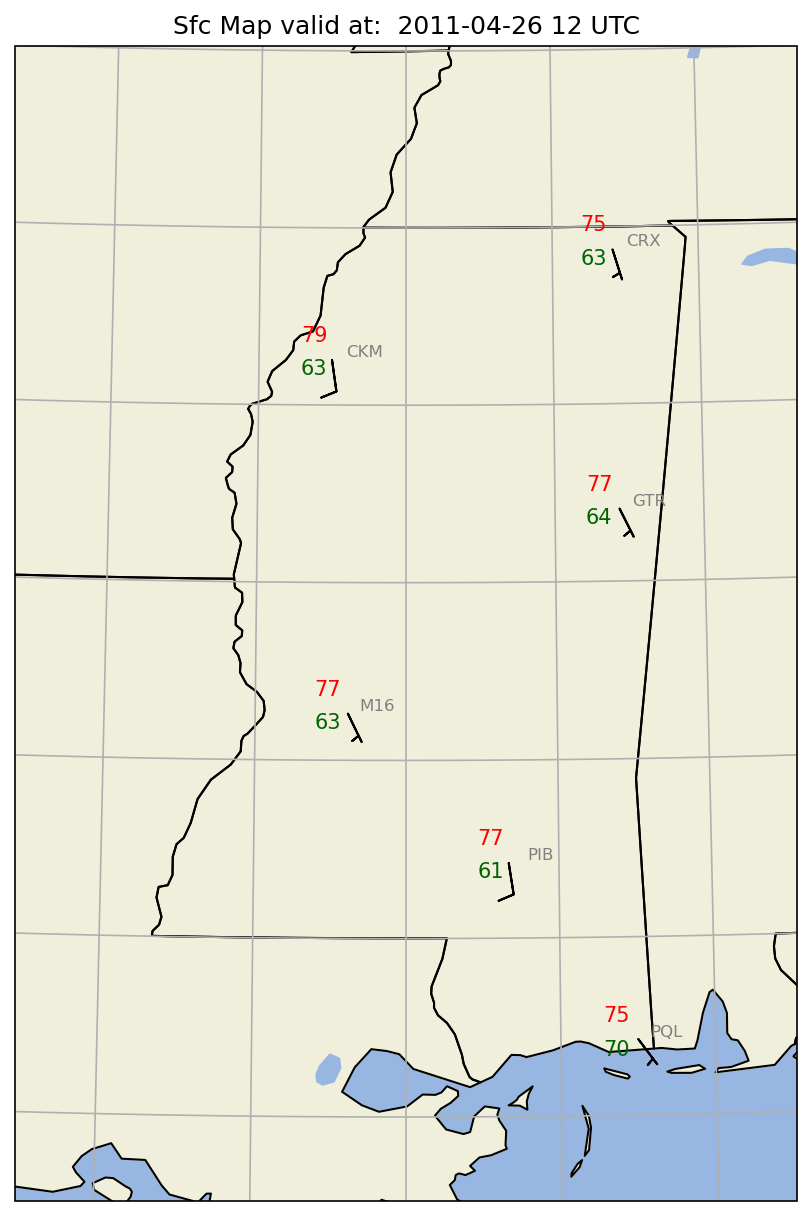

In [39]:
proj_map = ccrs.LambertConformal(central_longitude=cLon, central_latitude=cLat)
proj_data = ccrs.PlateCarree() 
res = '50m'

xy = proj_map.transform_points(proj_data, lons, lats)

density = 130000
mask = reduce_point_density(xy, density)
dpi = 150

fig = plt.figure(figsize=(12,10), dpi=dpi)

ax = fig.add_subplot(1, 1, 1, projection=proj_map)

ax.set_extent ((lonW-0.5,lonE+0.5,latS-0.5,latN+0.5), crs=proj_data)

ax.set_facecolor(cfeature.COLORS['water'])
land_mask = cfeature.NaturalEarthFeature('physical', 'land', res, edgecolor='face', facecolor=cfeature.COLORS['land'])
lake_mask = cfeature.NaturalEarthFeature('physical', 'lakes', res, edgecolor='face', facecolor=cfeature.COLORS['water'])
state_borders = cfeature.NaturalEarthFeature(category='cultural', name='admin_1_states_provinces_lakes', scale=res, facecolor='none')

ax.add_feature(land_mask)
ax.add_feature(lake_mask)
ax.add_feature(state_borders, linestyle='solid', edgecolor='black')
ax.gridlines()

stationplot = StationPlot(ax, lons[mask], lats[mask], transform=proj_data,
                          fontsize=8)

stationplot.plot_parameter('NW', tair[mask], color='red', fontsize=10)
stationplot.plot_parameter('SW', dewp[mask], color='darkgreen', fontsize=10)

stationplot.plot_parameter('NE', slp[mask], color='purple', formatter=lambda v: format(10 * v, '.0f')[-3:])



# stationplot.plot_symbol('C', cloud_cover[mask], sky_cover)
stationplot.plot_text((2, 0),stid[mask], color='gray')
#zorder - Higher value zorder will plot the variable on top of lower value zorder. This is necessary for wind barbs to appear. Default is 1.
stationplot.plot_barb(u[mask], v[mask],zorder=2)

plotTitle = (f"Sfc Map valid at:  {timeStr}")
ax.set_title (plotTitle);